# Clasificación automática de tipos de preguntas mediante Deep Learning
**TFM — Trabajo 2.3**

Este notebook implementa el pipeline completo descrito en la Memoria del proyecto:

1. Carga y análisis exploratorio del dataset TREC Question Classification
2. Preprocesamiento de los datos
3. Modelo base: TF-IDF + Logistic Regression
4. Redes recurrentes: LSTM y BiLSTM (PyTorch)
5. Transformers: BERT y DistilBERT (fine-tuning con Hugging Face)
6. Comparación de resultados (Accuracy, Precision, Recall, F1-Score, matriz de confusión)


Dataset: [TREC Question Classification Dataset (Kaggle)](https://www.kaggle.com/datasets/thedevastator/the-trec-question-classification-dataset-a-longi/data)


## 0. Instalación de dependencias


In [1]:
#!pip install -q transformers datasets evaluate torch scikit-learn pandas numpy matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


## 1. Imports y configuración

In [2]:
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

sns.set_theme(style="whitegrid")


Device: cpu


## 2. Carga de los datos

Se asume que `train.csv` y `test.csv` están en el mismo directorio del notebook
(en Colab, súbelos con el panel de archivos o monta Google Drive).

In [3]:
TRAIN_PATH = "train.csv"
TEST_PATH = "test.csv"

train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Test:", test_df.shape)
train_df.head()


Train: (5452, 3)
Test: (500, 3)


,label-coarse,label-fine,text
0,0,0,How did serfdom develop in and then leave Russ...
1,1,1,What films featured the character Popeye Doyle ?
2,0,0,How can I find a list of celebrities ' real na...
3,1,2,What fowl grabs the spotlight after the Chines...
4,2,3,What is the full form of .com ?


In [4]:
# Mapeo de las 6 categorías
LABEL_COARSE_MAP = {
    0: "DESC",  # Description / definición
    1: "ENTY",  # Entity / entidad
    2: "ABBR",  # Abbreviation / abreviatura
    3: "HUM",   # Human / persona
    4: "NUM",   # Numeric / número
    5: "LOC",   # Location / lugar
}

train_df["label_name"] = train_df["label-coarse"].map(LABEL_COARSE_MAP)
test_df["label_name"] = test_df["label-coarse"].map(LABEL_COARSE_MAP)

N_CLASSES = train_df["label-coarse"].nunique()
print("Número de clases:", N_CLASSES)
train_df["label_name"].value_counts()


Número de clases: 6


,count
label_name,
ENTY,1250
HUM,1223
DESC,1162
NUM,896
LOC,835
ABBR,86


## 3. Análisis exploratorio de los datos

In [5]:
# Comprobación de valores nulos y duplicados
print("Nulos en train:\n", train_df.isnull().sum())
print("\nDuplicados en train:", train_df.duplicated(subset=["text"]).sum())
print("Duplicados en test:", test_df.duplicated(subset=["text"]).sum())


Nulos en train:
 label-coarse    0
label-fine      0
text            0
label_name      0
dtype: int64

Duplicados en train: 71
Duplicados en test: 0


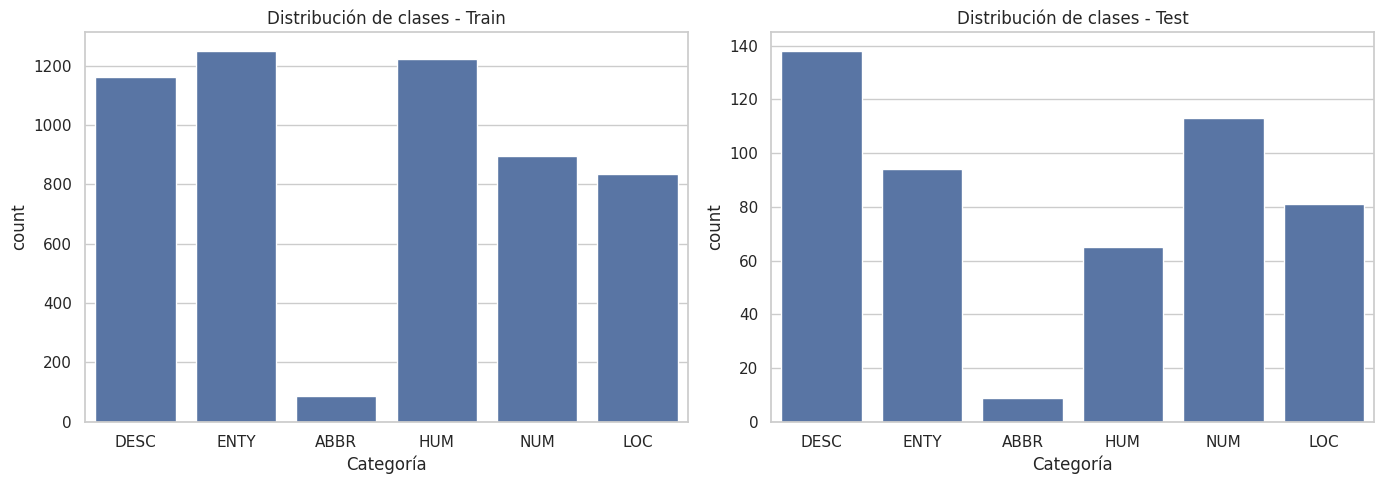

In [6]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=train_df, x="label_name", order=LABEL_COARSE_MAP.values(), ax=axes[0])
axes[0].set_title("Distribución de clases - Train")
axes[0].set_xlabel("Categoría")

sns.countplot(data=test_df, x="label_name", order=LABEL_COARSE_MAP.values(), ax=axes[1])
axes[1].set_title("Distribución de clases - Test")
axes[1].set_xlabel("Categoría")
plt.tight_layout()
plt.show()


count    5452.000000
mean       10.204696
std         3.889021
min         3.000000
25%         7.000000
50%        10.000000
75%        12.000000
max        37.000000
Name: n_words, dtype: float64


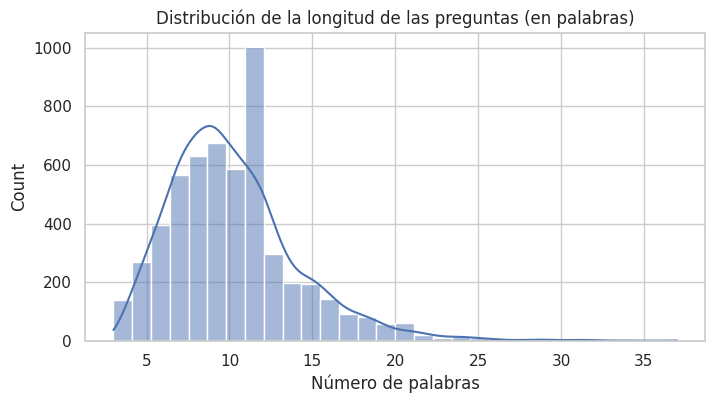

In [7]:
# Longitud de las preguntas
train_df["n_words"] = train_df["text"].str.split().str.len()
print(train_df["n_words"].describe())

plt.figure(figsize=(8, 4))
sns.histplot(train_df["n_words"], bins=30, kde=True)
plt.title("Distribución de la longitud de las preguntas (en palabras)")
plt.xlabel("Número de palabras")
plt.show()


In [8]:

print("Número de subcategorías (label-fine):", train_df["label-fine"].nunique())


Número de subcategorías (label-fine): 47


## 4. Preprocesamiento

Se aplican las etapas descritas en la propuesta: limpieza de texto, conversión a
minúsculas, eliminación de caracteres irrelevantes y división en
entrenamiento / validación. El conjunto `test.csv` se reserva como conjunto de
prueba final, sin tocar hasta la evaluación final de cada modelo.

In [9]:
def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = re.sub(r"[^a-z0-9À-ÿ\s'?.,]", " ", text)  # elimina caracteres especiales irrelevantes
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head()


,text,clean_text
0,How did serfdom develop in and then leave Russ...,how did serfdom develop in and then leave russ...
1,What films featured the character Popeye Doyle ?,what films featured the character popeye doyle ?
2,How can I find a list of celebrities ' real na...,how can i find a list of celebrities ' real na...
3,What fowl grabs the spotlight after the Chines...,what fowl grabs the spotlight after the chines...
4,What is the full form of .com ?,what is the full form of .com ?


In [10]:
# División 85/15 de train -> train/validación (test.csv se usa como test final)
train_split, val_split = train_test_split(
    train_df, test_size=0.15, random_state=SEED, stratify=train_df["label-coarse"]
)
print("Train:", train_split.shape, "Val:", val_split.shape, "Test:", test_df.shape)


Train: (4634, 6) Val: (818, 6) Test: (500, 5)


## 5. Modelo base: TF-IDF + Logistic Regression

Modelo tradicional de referencia (Machine Learning clásico)

In [11]:
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))

X_train_tfidf = tfidf.fit_transform(train_split["clean_text"])
X_val_tfidf = tfidf.transform(val_split["clean_text"])
X_test_tfidf = tfidf.transform(test_df["clean_text"])

y_train = train_split["label-coarse"].values
y_val = val_split["label-coarse"].values
y_test = test_df["label-coarse"].values

logreg = LogisticRegression(max_iter=1000, C=1.0)
logreg.fit(X_train_tfidf, y_train)


LogisticRegression(max_iter=1000)

In [12]:
def evaluate_predictions(y_true, y_pred, model_name, label_map=LABEL_COARSE_MAP):
    """Calcula y muestra las métricas estándar para un modelo."""
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    print(f"\n=== {model_name} ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision (macro): {precision:.4f}")
    print(f"Recall (macro)   : {recall:.4f}")
    print(f"F1-score (macro) : {f1:.4f}\n")
    print(classification_report(
        y_true, y_pred,
        target_names=[label_map[i] for i in sorted(label_map)],
        zero_division=0
    ))
    return {"model": model_name, "accuracy": acc, "precision": precision, "recall": recall, "f1": f1}


def plot_confusion_matrix(y_true, y_pred, model_name, label_map=LABEL_COARSE_MAP):
    cm = confusion_matrix(y_true, y_pred)
    labels = [label_map[i] for i in sorted(label_map)]
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.title(f"Matriz de confusión - {model_name}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()


results = []



=== Logistic Regression + TF-IDF ===
Accuracy : 0.8560
Precision (macro): 0.8930
Recall (macro)   : 0.8361
F1-score (macro) : 0.8585

              precision    recall  f1-score   support

        DESC       0.78      0.99      0.87       138
        ENTY       0.76      0.72      0.74        94
        ABBR       1.00      0.78      0.88         9
         HUM       0.92      0.89      0.91        65
         NUM       1.00      0.82      0.90       113
         LOC       0.89      0.81      0.85        81

    accuracy                           0.86       500
   macro avg       0.89      0.84      0.86       500
weighted avg       0.87      0.86      0.86       500



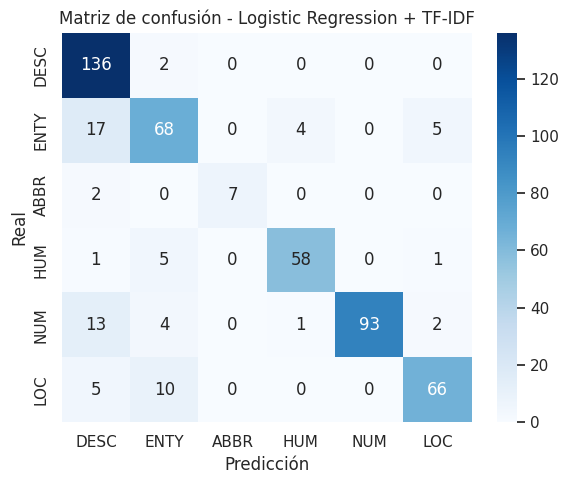

In [13]:
y_pred_logreg = logreg.predict(X_test_tfidf)
results.append(evaluate_predictions(y_test, y_pred_logreg, "Logistic Regression + TF-IDF"))
plot_confusion_matrix(y_test, y_pred_logreg, "Logistic Regression + TF-IDF")


## 6. Redes neuronales recurrentes: LSTM y BiLSTM

Implementación con PyTorch. Se construye un vocabulario propio a partir de los datos de
entrenamiento y se entrena un embedding desde cero.

In [14]:
from collections import Counter

def tokenize(text):
    return text.split()


counter = Counter()
for t in train_split["clean_text"]:
    counter.update(tokenize(t))

MIN_FREQ = 1
vocab = {"<pad>": 0, "<unk>": 1}
for word, freq in counter.items():
    if freq >= MIN_FREQ:
        vocab[word] = len(vocab)

VOCAB_SIZE = len(vocab)
print("Tamaño del vocabulario:", VOCAB_SIZE)

def encode(text, max_len=30):
    tokens = tokenize(text)[:max_len]
    ids = [vocab.get(tok, vocab["<unk>"]) for tok in tokens]
    ids = ids + [vocab["<pad>"]] * (max_len - len(ids))
    return ids

MAX_LEN = 30


Tamaño del vocabulario: 7738


In [15]:
class QuestionDataset(Dataset):
    def __init__(self, df, max_len=MAX_LEN):
        self.texts = df["clean_text"].values
        self.labels = df["label-coarse"].values
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        ids = encode(self.texts[idx], self.max_len)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


train_ds = QuestionDataset(train_split)
val_ds = QuestionDataset(val_split)
test_ds = QuestionDataset(test_df)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE)


In [16]:
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128, n_classes=N_CLASSES,
                 bidirectional=False, n_layers=1, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim, num_layers=n_layers,
            bidirectional=bidirectional, batch_first=True,
            dropout=dropout if n_layers > 1 else 0.0
        )
        mult = 2 if bidirectional else 1
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * mult, n_classes)

    def forward(self, x):
        embedded = self.embedding(x)
        output, (hidden, cell) = self.lstm(embedded)
        if self.lstm.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
        else:
            hidden_cat = hidden[-1]
        out = self.dropout(hidden_cat)
        return self.fc(out)


In [17]:
def train_torch_model(model, train_loader, val_loader, n_epochs=10, lr=1e-3, patience=3):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_loss = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(n_epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * x.size(0)
            train_correct += (logits.argmax(1) == y).sum().item()
            train_total += x.size(0)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item() * x.size(0)
                val_correct += (logits.argmax(1) == y).sum().item()
                val_total += x.size(0)

        train_loss /= train_total
        val_loss /= val_total
        train_acc = train_correct / train_total
        val_acc = val_correct / val_total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{n_epochs} - "
              f"train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} - "
              f"val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}")


        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping activado.")
                break

    model.load_state_dict(best_state)
    return model, history


def plot_learning_curves(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["train_loss"], label="Train")
    axes[0].plot(history["val_loss"], label="Val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Época")
    axes[0].legend()

    axes[1].plot(history["train_acc"], label="Train")
    axes[1].plot(history["val_acc"], label="Val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].set_xlabel("Época")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


@torch.no_grad()
def predict_torch_model(model, loader):
    model.eval()
    preds, trues = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        logits = model(x)
        preds.extend(logits.argmax(1).cpu().numpy())
        trues.extend(y.numpy())
    return np.array(trues), np.array(preds)


Epoch 1/15 - train_loss: 1.6763 train_acc: 0.2188 - val_loss: 1.6538 val_acc: 0.2249
Epoch 2/15 - train_loss: 1.6471 train_acc: 0.2374 - val_loss: 1.6147 val_acc: 0.3570
Epoch 3/15 - train_loss: 1.4937 train_acc: 0.3623 - val_loss: 1.4048 val_acc: 0.3399
Epoch 4/15 - train_loss: 1.1664 train_acc: 0.5265 - val_loss: 1.0927 val_acc: 0.5575
Epoch 5/15 - train_loss: 0.8583 train_acc: 0.6858 - val_loss: 0.9518 val_acc: 0.6797
Epoch 6/15 - train_loss: 0.6418 train_acc: 0.7946 - val_loss: 0.9111 val_acc: 0.7005
Epoch 7/15 - train_loss: 0.5054 train_acc: 0.8589 - val_loss: 0.9500 val_acc: 0.7103
Epoch 8/15 - train_loss: 0.4064 train_acc: 0.8910 - val_loss: 0.9403 val_acc: 0.7311
Epoch 9/15 - train_loss: 0.3509 train_acc: 0.9050 - val_loss: 0.9177 val_acc: 0.7604
Early stopping activado.


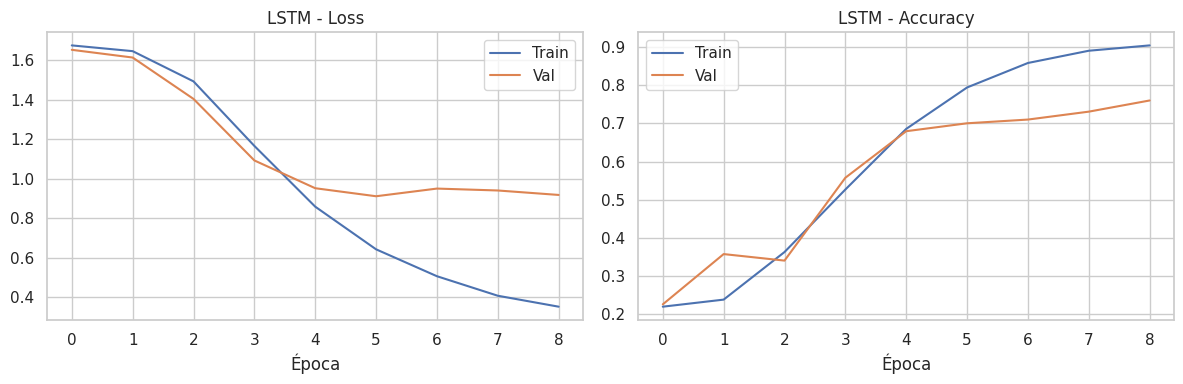


=== LSTM ===
Accuracy : 0.7540
Precision (macro): 0.8227
Recall (macro)   : 0.7287
F1-score (macro) : 0.7611

              precision    recall  f1-score   support

        DESC       0.69      0.92      0.79       138
        ENTY       0.65      0.60      0.62        94
        ABBR       1.00      0.67      0.80         9
         HUM       0.98      0.77      0.86        65
         NUM       0.99      0.72      0.83       113
         LOC       0.63      0.70      0.66        81

    accuracy                           0.75       500
   macro avg       0.82      0.73      0.76       500
weighted avg       0.78      0.75      0.76       500



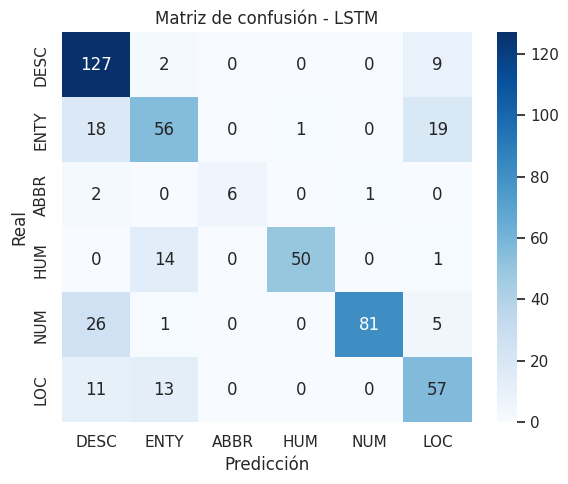

In [18]:
# --- LSTM ---
lstm_model = LSTMClassifier(VOCAB_SIZE, bidirectional=False)
lstm_model, lstm_history = train_torch_model(lstm_model, train_loader, val_loader, n_epochs=15, lr=1e-3)
plot_learning_curves(lstm_history, "LSTM")

y_true_lstm, y_pred_lstm = predict_torch_model(lstm_model, test_loader)
results.append(evaluate_predictions(y_true_lstm, y_pred_lstm, "LSTM"))
plot_confusion_matrix(y_true_lstm, y_pred_lstm, "LSTM")


Epoch 1/15 - train_loss: 1.0735 train_acc: 0.6021 - val_loss: 0.7587 val_acc: 0.7262
Epoch 2/15 - train_loss: 0.6038 train_acc: 0.7859 - val_loss: 0.6405 val_acc: 0.7665
Epoch 3/15 - train_loss: 0.4010 train_acc: 0.8686 - val_loss: 0.5786 val_acc: 0.7946
Epoch 4/15 - train_loss: 0.2487 train_acc: 0.9204 - val_loss: 0.5884 val_acc: 0.8154
Epoch 5/15 - train_loss: 0.1365 train_acc: 0.9590 - val_loss: 0.6366 val_acc: 0.8130
Epoch 6/15 - train_loss: 0.0619 train_acc: 0.9864 - val_loss: 0.7822 val_acc: 0.7910
Early stopping activado.


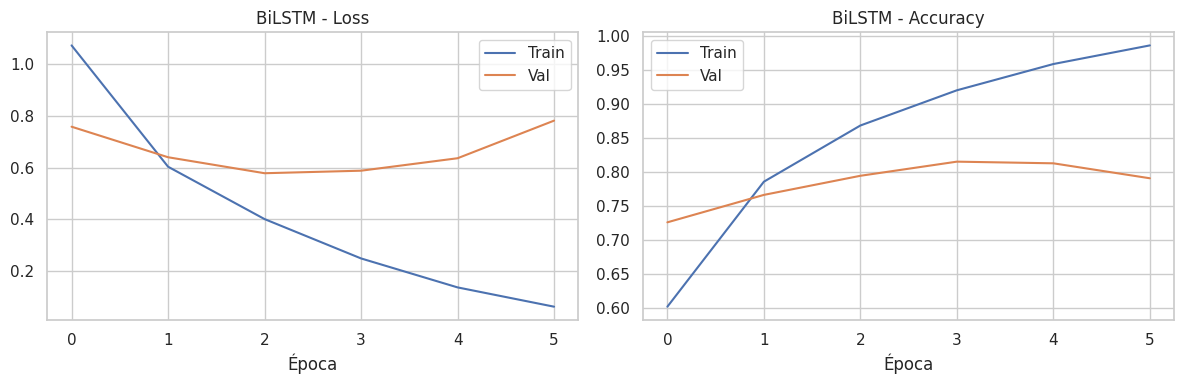


=== BiLSTM ===
Accuracy : 0.8260
Precision (macro): 0.8528
Recall (macro)   : 0.7914
F1-score (macro) : 0.8133

              precision    recall  f1-score   support

        DESC       0.80      0.97      0.88       138
        ENTY       0.73      0.61      0.66        94
        ABBR       1.00      0.67      0.80         9
         HUM       0.80      0.88      0.84        65
         NUM       0.91      0.85      0.88       113
         LOC       0.88      0.78      0.82        81

    accuracy                           0.83       500
   macro avg       0.85      0.79      0.81       500
weighted avg       0.83      0.83      0.82       500



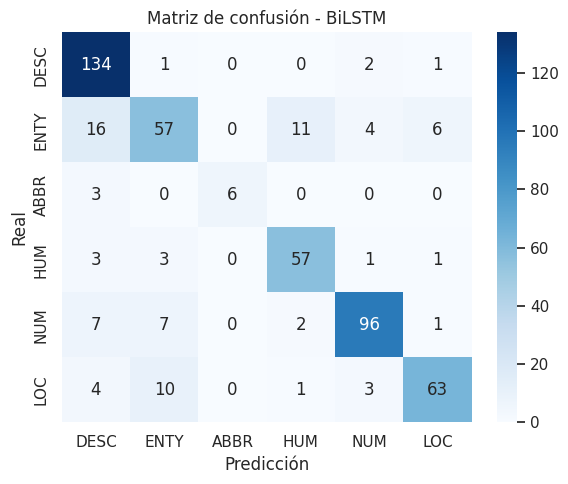

In [19]:
# --- BiLSTM ---
bilstm_model = LSTMClassifier(VOCAB_SIZE, bidirectional=True)
bilstm_model, bilstm_history = train_torch_model(bilstm_model, train_loader, val_loader, n_epochs=15, lr=1e-3)
plot_learning_curves(bilstm_history, "BiLSTM")

y_true_bilstm, y_pred_bilstm = predict_torch_model(bilstm_model, test_loader)
results.append(evaluate_predictions(y_true_bilstm, y_pred_bilstm, "BiLSTM"))
plot_confusion_matrix(y_true_bilstm, y_pred_bilstm, "BiLSTM")


## 7. Modelos basados en Transformers: BERT y DistilBERT

Fine-tuning mediante transferencia de aprendizaje mediante la librería
Hugging Face `transformers`, tal como se describe en las secciones 4.b y 4.c
de la propuesta. Se recomienda ejecutar esta sección con GPU (Google Colab).

In [20]:
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from datasets import Dataset as HFDataset
import evaluate

# Datasets de Hugging Face a partir de los splits ya creados
hf_train = HFDataset.from_pandas(train_split[["clean_text", "label-coarse"]].rename(
    columns={"clean_text": "text", "label-coarse": "label"}
).reset_index(drop=True))
hf_val = HFDataset.from_pandas(val_split[["clean_text", "label-coarse"]].rename(
    columns={"clean_text": "text", "label-coarse": "label"}
).reset_index(drop=True))
hf_test = HFDataset.from_pandas(test_df[["clean_text", "label-coarse"]].rename(
    columns={"clean_text": "text", "label-coarse": "label"}
).reset_index(drop=True))

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)["accuracy"]
    f1 = f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"]
    return {"accuracy": acc, "f1": f1}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [21]:
def fine_tune_transformer(model_checkpoint, output_dir, n_epochs=4, lr=2e-5, batch_size=16):
    tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)

    def tokenize_fn(batch):
        return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=32)

    train_tok = hf_train.map(tokenize_fn, batched=True)
    val_tok = hf_val.map(tokenize_fn, batched=True)
    test_tok = hf_test.map(tokenize_fn, batched=True)

    model = AutoModelForSequenceClassification.from_pretrained(
        model_checkpoint, num_labels=N_CLASSES
    )

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=lr,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=n_epochs,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        report_to="none",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_tok,
        eval_dataset=val_tok,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    trainer.train()

    test_preds = trainer.predict(test_tok)
    y_pred = np.argmax(test_preds.predictions, axis=-1)
    y_true = np.array(test_tok["label"])

    return trainer, y_true, y_pred


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



=== DistilBERT ===
Accuracy : 0.9640
Precision (macro): 0.9688
Recall (macro)   : 0.9506
F1-score (macro) : 0.9585

              precision    recall  f1-score   support

        DESC       0.96      1.00      0.98       138
        ENTY       0.98      0.87      0.92        94
        ABBR       1.00      0.89      0.94         9
         HUM       0.96      0.98      0.97        65
         NUM       0.98      0.98      0.98       113
         LOC       0.94      0.98      0.96        81

    accuracy                           0.96       500
   macro avg       0.97      0.95      0.96       500
weighted avg       0.96      0.96      0.96       500



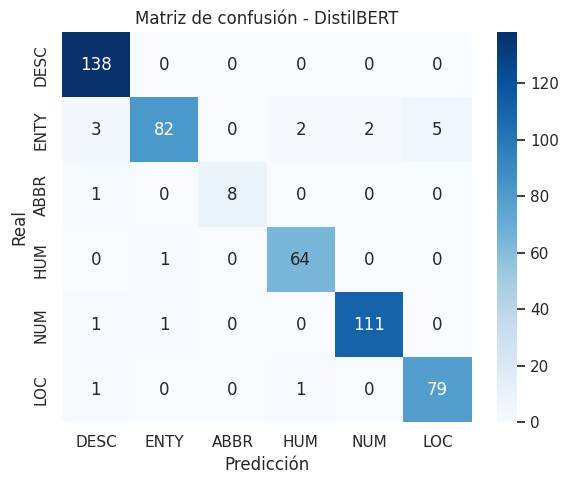

In [22]:
# --- DistilBERT ---
distilbert_trainer, y_true_distil, y_pred_distil = fine_tune_transformer(
    "distilbert-base-uncased", output_dir="./distilbert_output", n_epochs=4, lr=5e-5
)
results.append(evaluate_predictions(y_true_distil, y_pred_distil, "DistilBERT"))
plot_confusion_matrix(y_true_distil, y_pred_distil, "DistilBERT")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/4634 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte


=== BERT ===
Accuracy : 0.9680
Precision (macro): 0.9734
Recall (macro)   : 0.9549
F1-score (macro) : 0.9631

              precision    recall  f1-score   support

        DESC       0.96      0.99      0.97       138
        ENTY       0.98      0.88      0.93        94
        ABBR       1.00      0.89      0.94         9
         HUM       0.97      0.98      0.98        65
         NUM       0.97      1.00      0.98       113
         LOC       0.96      0.99      0.98        81

    accuracy                           0.97       500
   macro avg       0.97      0.95      0.96       500
weighted avg       0.97      0.97      0.97       500



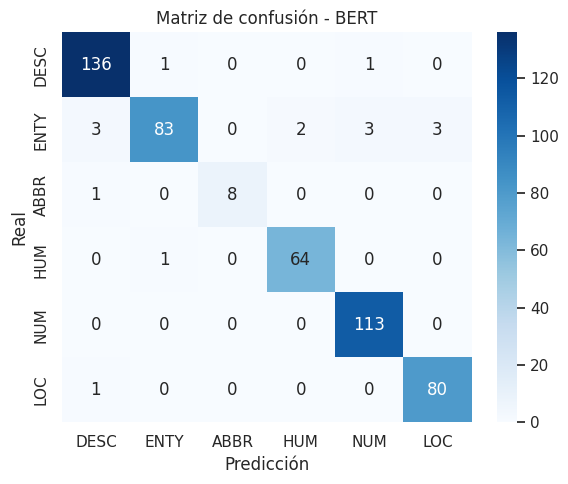

In [23]:
# --- BERT ---
bert_trainer, y_true_bert, y_pred_bert = fine_tune_transformer(
    "bert-base-uncased", output_dir="./bert_output", n_epochs=4, lr=2e-5
)
results.append(evaluate_predictions(y_true_bert, y_pred_bert, "BERT"))
plot_confusion_matrix(y_true_bert, y_pred_bert, "BERT")


## 8. Comparación final de modelos

Tabla y gráfico comparativo de Accuracy, Precision, Recall y F1-Score
para todos los modelos evaluados

In [24]:
results_df = pd.DataFrame(results).sort_values("f1", ascending=False).reset_index(drop=True)
results_df


,model,accuracy,precision,recall,f1
0,BERT,0.968,0.973396,0.954941,0.963130
1,DistilBERT,0.964,0.968754,0.950576,0.958470
2,Logistic Regression + TF-IDF,0.856,0.893030,0.836137,0.858457
3,BiLSTM,0.826,0.852774,0.791387,0.813326
4,LSTM,0.754,0.822658,0.728742,0.761112


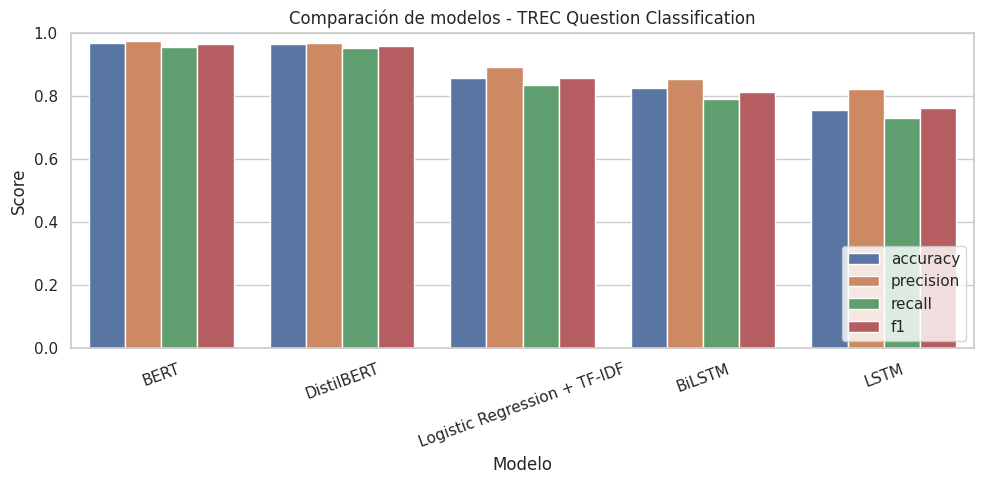

In [25]:
results_melted = results_df.melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(10, 5))
sns.barplot(data=results_melted, x="model", y="score", hue="metric")
plt.title("Comparación de modelos - TREC Question Classification")
plt.ylabel("Score")
plt.xlabel("Modelo")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


## 9. Criterio de validez para producción

Para validar un modelo se considera apto para
producción si:

- Accuracy > 90%
- F1-Score (macro) > 0.90
- Rendimiento estable entre validación y test (sin sobreajuste significativo)


In [26]:
PROD_ACC_THRESHOLD = 0.90
PROD_F1_THRESHOLD = 0.90

results_df["apto_para_produccion"] = (
    (results_df["accuracy"] > PROD_ACC_THRESHOLD) &
    (results_df["f1"] > PROD_F1_THRESHOLD)
)
results_df


,model,accuracy,precision,recall,f1,apto_para_produccion
0,BERT,0.968,0.973396,0.954941,0.963130,True
1,DistilBERT,0.964,0.968754,0.950576,0.958470,True
2,Logistic Regression + TF-IDF,0.856,0.893030,0.836137,0.858457,False
3,BiLSTM,0.826,0.852774,0.791387,0.813326,False
4,LSTM,0.754,0.822658,0.728742,0.761112,False


## 10. Guardado del mejor modelo

El mejor modelo (según F1-Score macro) se guarda para su posterior despliegue,
en formato compatible con Hugging Face (`.bin`/`.safetensors` + tokenizer) o
PyTorch (`.pt`), según corresponda (sección 8.b de la propuesta).

In [27]:
best_model_name = results_df.iloc[0]["model"]
print("Mejor modelo:", best_model_name)

distilbert_trainer.save_model("./best_model_distilbert")
tokenizer.save_pretrained("./best_model_distilbert")
torch.save(bilstm_model.state_dict(), "bilstm_model.pt")


Mejor modelo: BERT
